In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

**Helper functions**

In [2]:
def read_curve(filename: str, column_name: str):
    '''Reads a csv file and returns the x and y values for a given column name (y or y_simulated)'''
    df = pd.read_csv(filename)

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in the CSV file {filename}.")
    
    df = df[["x", column_name]].dropna().sort_values("x")

    x = df["x"].to_numpy()
    y = df[column_name].to_numpy()

    return x, y

In [3]:
def use_curve(input_values: np.ndarray, curve_x: np.ndarray, curve_y: np.ndarray):
    '''Estimates the y values for given input x values using linear interpolation based on prodived curves'''
    return np.interp(input_values, curve_x, curve_y, left=curve_y[0], right=curve_y[-1])

**Gaussian (Feynman I.6.2)**

In [4]:
f_I_6_2 = lambda theta, sigma: np.exp(-theta**2/(2*sigma**2))/np.sqrt(2*np.pi*sigma**2)

theta = np.linspace(-1, 1, 101)
sigma = np.linspace(0.5, 2, 101)
theta_grid, sigma_grid = np.meshgrid(theta, sigma)

In [5]:
def compute_KAN_tree(theta_grid: np.ndarray, sigma_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_6_2/")

    theta0_x, theta0_y = read_curve(curves_dir/"theta0_fit_curve.csv", column_name)
    theta1_x, theta1_y = read_curve(curves_dir/"theta1_fit_curve.csv", column_name)
    sigma0_x, sigma0_y = read_curve(curves_dir/"sigma0_fit_curve.csv", column_name)
    sigma1_x, sigma1_y = read_curve(curves_dir/"sigma1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    theta0_out = use_curve(theta_grid, theta0_x, theta0_y)
    theta1_out = use_curve(theta_grid, theta1_x, theta1_y)

    sigma0_out = use_curve(sigma_grid, sigma0_x, sigma0_y)
    sigma1_out = use_curve(sigma_grid, sigma1_x, sigma1_y)

    node1_0_in = theta0_out + sigma0_out
    node1_1_in = theta1_out + sigma1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [6]:
Z_true = f_I_6_2(theta_grid, sigma_grid)
Z_KAN = compute_KAN_tree(theta_grid, sigma_grid, column_name="y")
Z_simulated = compute_KAN_tree(theta_grid, sigma_grid, column_name="y_simulated")

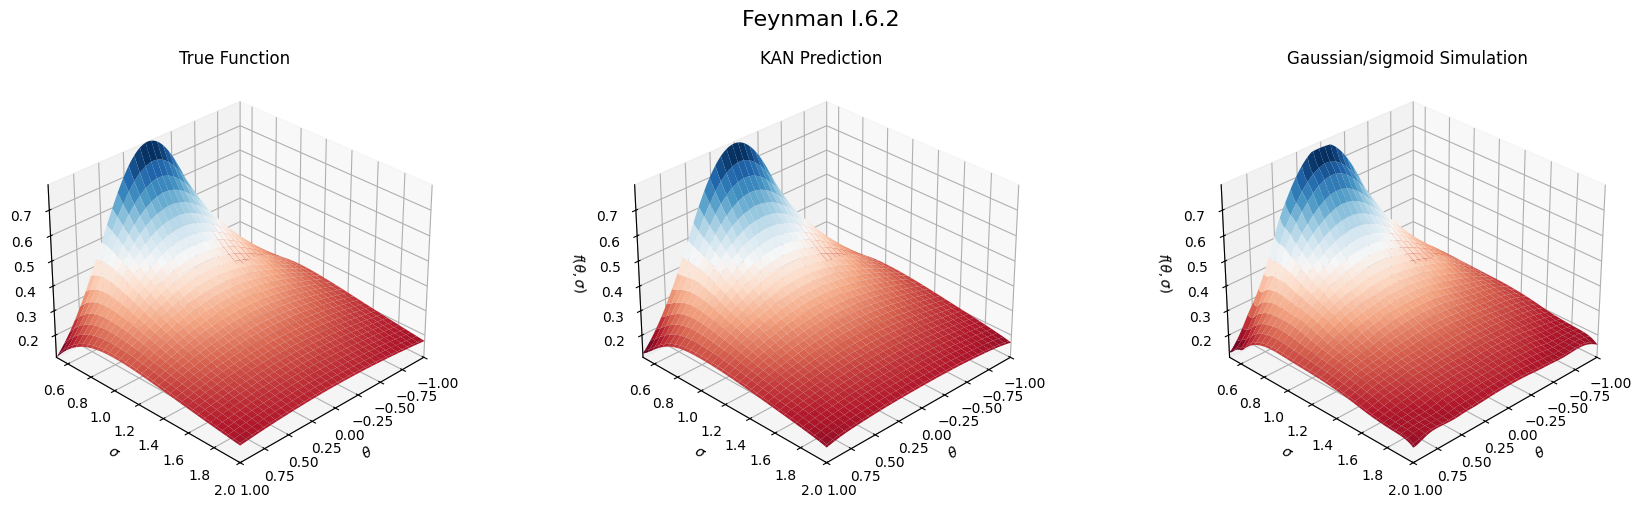

In [7]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(theta_grid, sigma_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("$\\theta$")
ax1.set_ylabel("$\\sigma$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(theta_grid, sigma_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("$\\theta$")
ax2.set_ylabel("$\\sigma$")
ax2.set_zlabel("$f(\\theta, \\sigma)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(theta_grid, sigma_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("$\\theta$")
ax3.set_ylabel("$\\sigma$")
ax3.set_zlabel("$f(\\theta, \\sigma)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.6.2", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.12.11**

In [8]:
f_I_12_11 = lambda a, theta: 1 + a * np.sin(theta)

a = np.linspace(-1, 1, 101)
theta = np.linspace(0, 2*np.pi, 100)
a_grid, theta_grid = np.meshgrid(a, theta)

In [9]:
def compute_KAN_tree(a_grid: np.ndarray, theta_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_12_11/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    theta0_x, theta0_y = read_curve(curves_dir/"theta0_fit_curve.csv", column_name)
    theta1_x, theta1_y = read_curve(curves_dir/"theta1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    theta0_out = use_curve(theta_grid, theta0_x, theta0_y)
    theta1_out = use_curve(theta_grid, theta1_x, theta1_y)

    node1_0_in = a0_out + theta0_out
    node1_1_in = a1_out + theta1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [10]:
Z_true = f_I_12_11(a_grid, theta_grid)
Z_KAN = compute_KAN_tree(a_grid, theta_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, theta_grid, column_name="y_simulated")

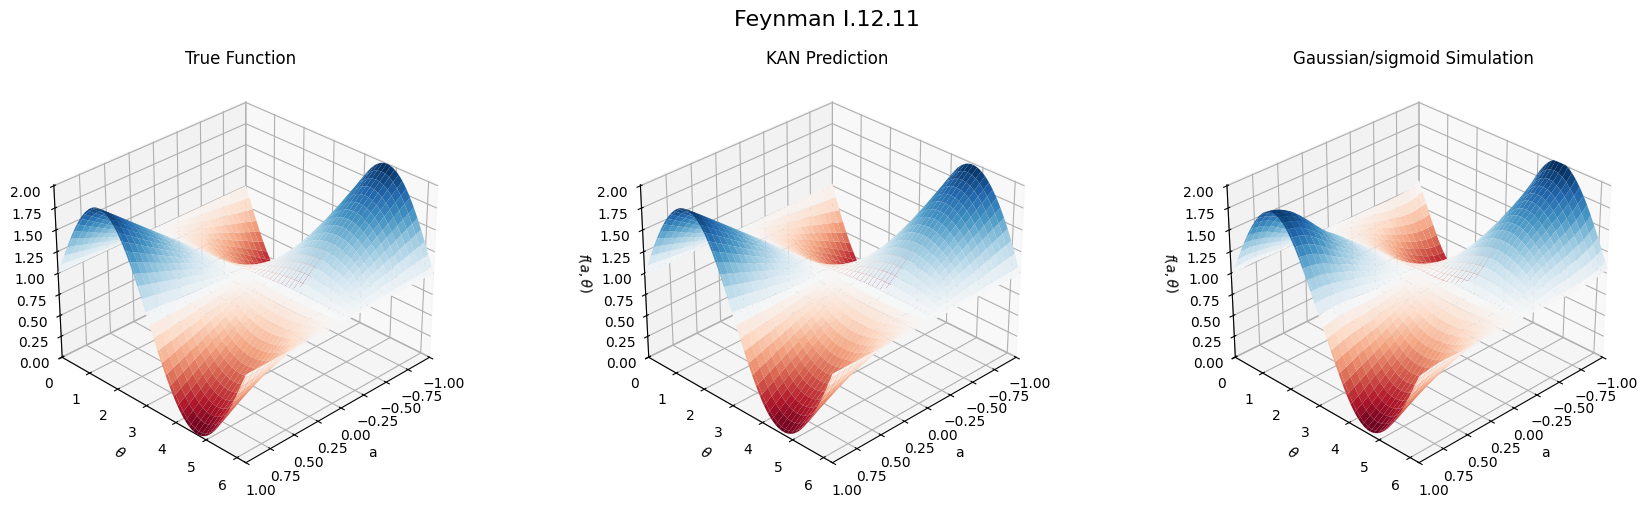

In [11]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, theta_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("$\\theta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, theta_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("$\\theta$")
ax2.set_zlabel("$f(a, \\theta)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, theta_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("$\\theta$")
ax3.set_zlabel("$f(a, \\theta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 2*np.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.12.11", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.13.12**

In [14]:
f_I_13_12 = lambda a, b: a*(1/b - 1)

a = np.linspace(0, 1, 101)
b = np.linspace(0.5, 2, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [15]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_13_12/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    b1_x, b1_y = read_curve(curves_dir/"b1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)
    b1_out = use_curve(b_grid, b1_x, b1_y)

    node1_0_in = a0_out + b0_out
    node1_1_in = a1_out + b1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [16]:
Z_true = f_I_13_12(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

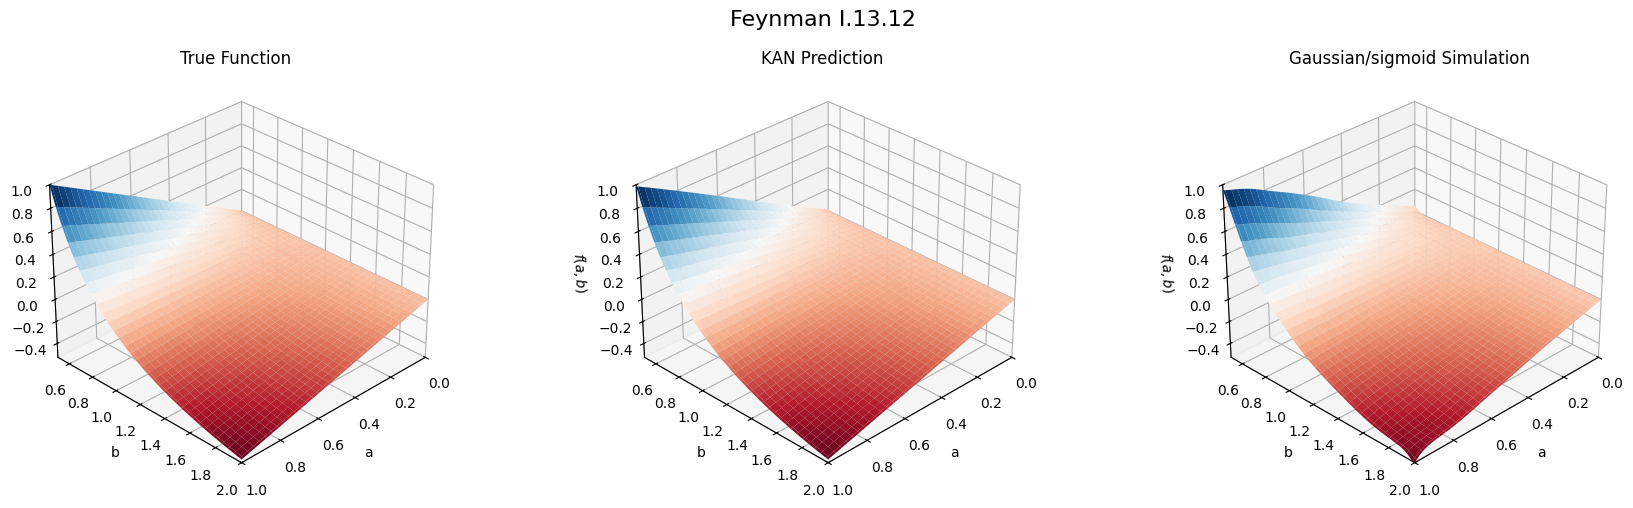

In [17]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.13.12", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.15.3x**

In [18]:
f_I_15_3x = lambda a, b: (1-a)/ np.sqrt(1 - b**2)

a = np.linspace(-1, 1, 101)
b = np.linspace(-0.9, 0.9, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [19]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_15_3x/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)

    node1_0_in = a0_out + b0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [20]:
Z_true = f_I_15_3x(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

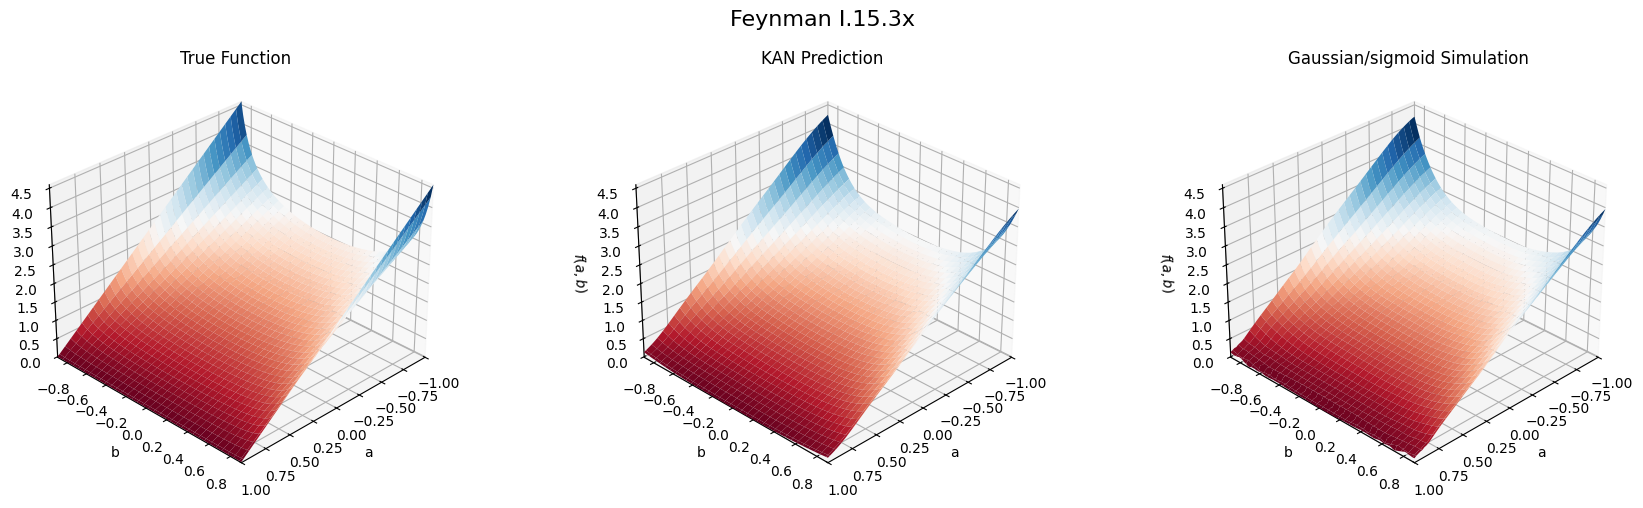

In [21]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.9, 0.9)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.15.3x", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.16.6**

In [22]:
f_I_16_6 = lambda a, b: (a+b) / (1 + a*b)

a = np.linspace(-0.8, 0.8, 101)
b = np.linspace(-0.8, 0.8, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [23]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_16_6/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    b1_x, b1_y = read_curve(curves_dir/"b1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)
    b1_out = use_curve(b_grid, b1_x, b1_y)

    node1_0_in = a0_out + b0_out
    node1_1_in = a1_out + b1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [24]:
Z_true = f_I_16_6(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

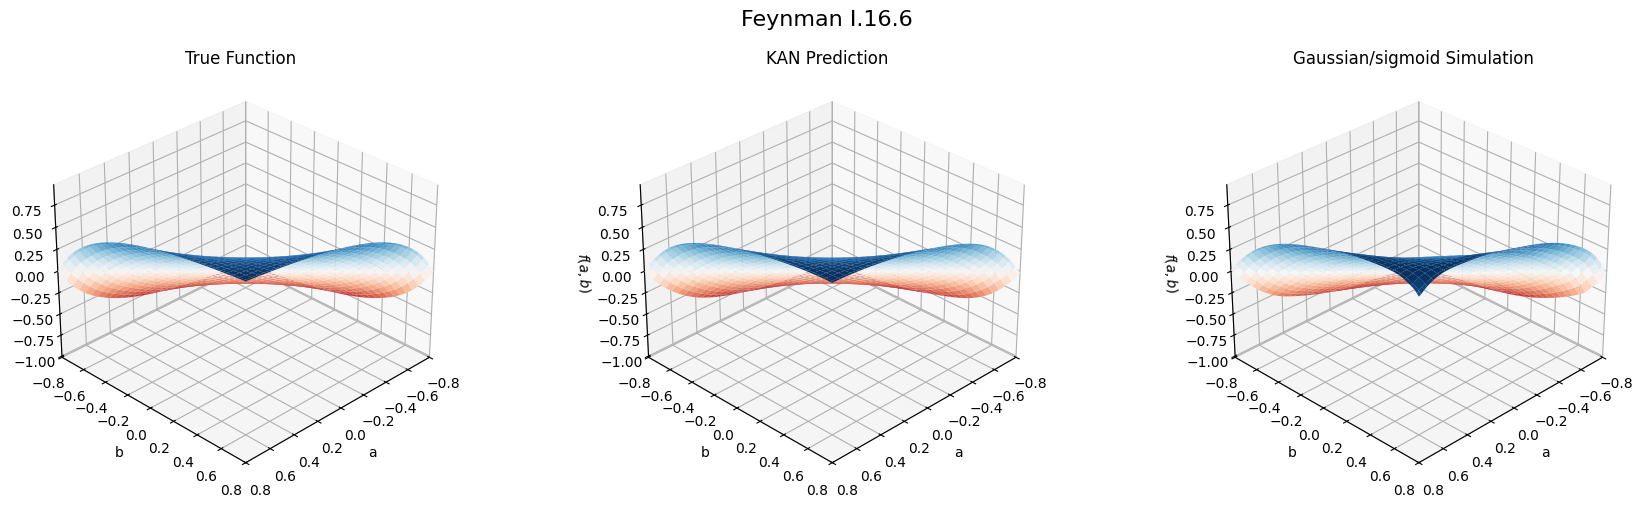

In [25]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.16.6", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.18.4**

In [26]:
f_I_18_4 = lambda a, b: (1 + a*b) / (1 + a)

a = np.linspace(0.5, 2, 101)
b = np.linspace(-1, 1, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [27]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_18_4/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    b1_x, b1_y = read_curve(curves_dir/"b1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)
    b1_out = use_curve(b_grid, b1_x, b1_y)

    node1_0_in = a0_out + b0_out
    node1_1_in = a1_out + b1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [28]:
Z_true = f_I_18_4(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

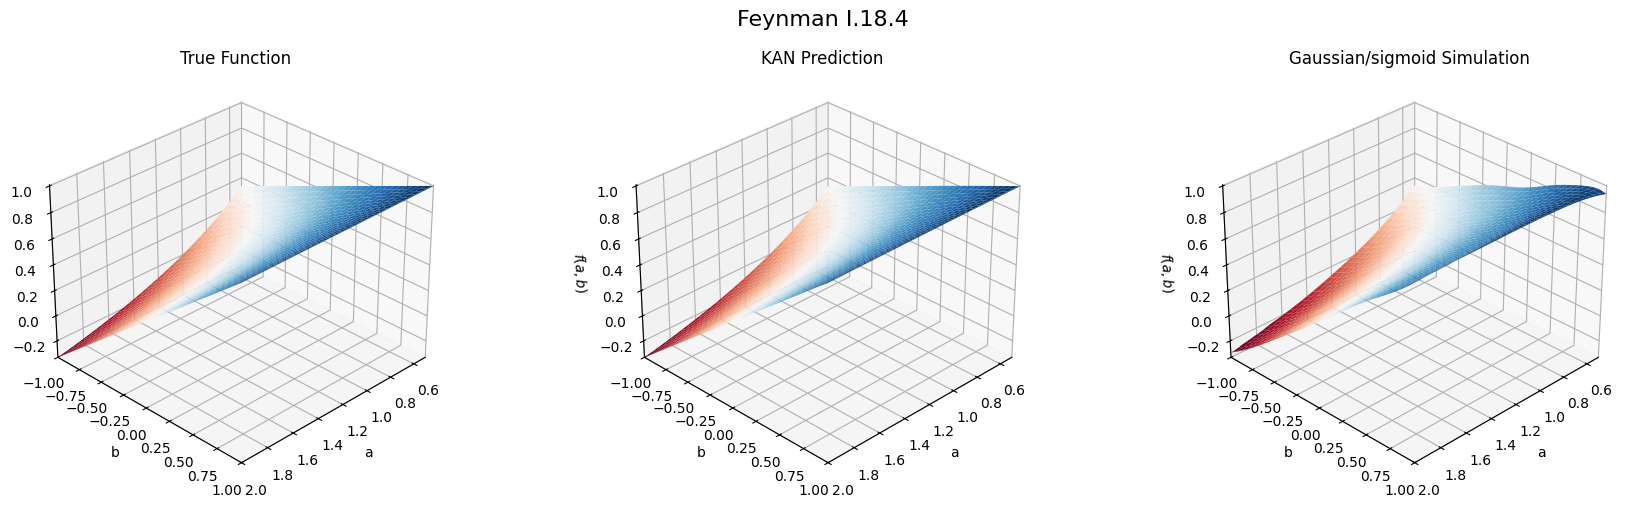

In [29]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0.5, 2)
    ax.set_ylim(-1, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.18.4", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.26.2**

In [30]:
f_I_26_2 = lambda n, theta: np.arcsin(n * np.sin(theta))

n = np.linspace(0, 0.99, 101)
theta = np.linspace(0, 2*np.pi, 101)
n_grid, theta_grid = np.meshgrid(n, theta)

In [31]:
def compute_KAN_tree(n_grid: np.ndarray, theta_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_26_2/")

    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    n1_x, n1_y = read_curve(curves_dir/"n1_fit_curve.csv", column_name)
    theta0_x, theta0_y = read_curve(curves_dir/"theta0_fit_curve.csv", column_name)
    theta1_x, theta1_y = read_curve(curves_dir/"theta1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    n0_out = use_curve(n_grid, n0_x, n0_y)
    n1_out = use_curve(n_grid, n1_x, n1_y)

    theta0_out = use_curve(theta_grid, theta0_x, theta0_y)
    theta1_out = use_curve(theta_grid, theta1_x, theta1_y)

    node1_0_in = n0_out + theta0_out
    node1_1_in = n1_out + theta1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [32]:
Z_true = f_I_26_2(n_grid, theta_grid)
Z_KAN = compute_KAN_tree(n_grid, theta_grid, column_name="y")
Z_simulated = compute_KAN_tree(n_grid, theta_grid, column_name="y_simulated")

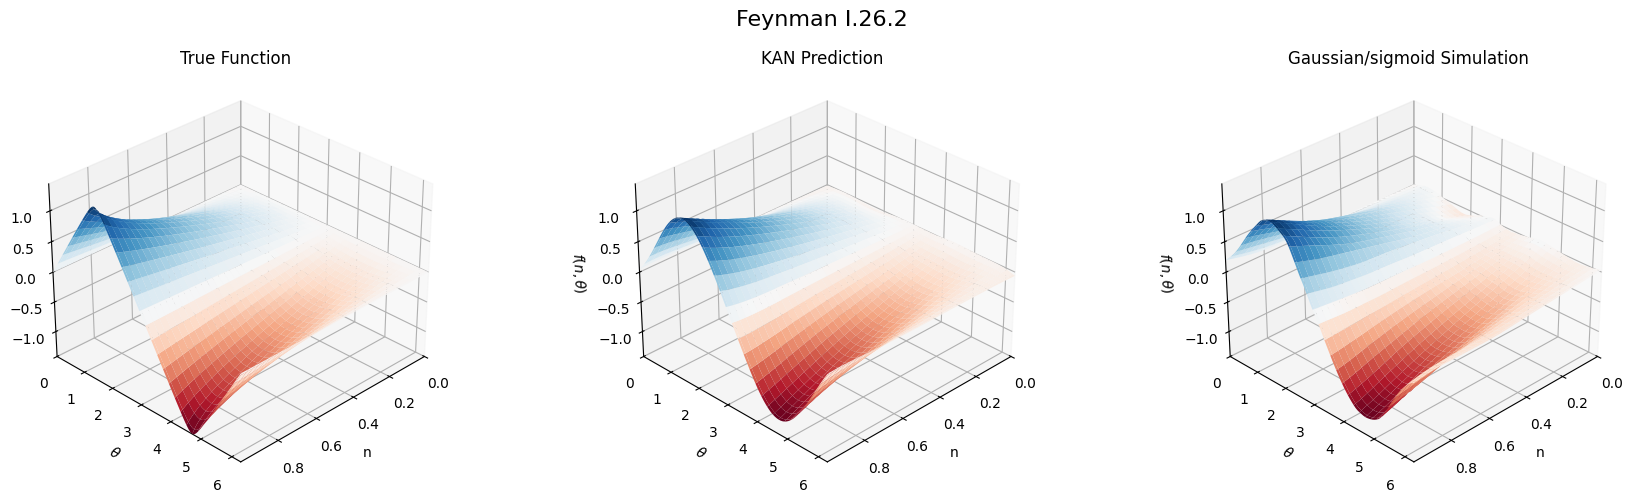

In [33]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(n_grid, theta_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("$\\theta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(n_grid, theta_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("$\\theta$")
ax2.set_zlabel("$f(n, \\theta)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(n_grid, theta_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("n")
ax3.set_ylabel("$\\theta$")
ax3.set_zlabel("$f(n, \\theta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 0.99)
    ax.set_ylim(0, 2*np.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.26.2", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.27.6**

In [34]:
f_I_27_6 = lambda a, b: 1/(1 + a*b)

a = np.linspace(0.25, 2, 101)
b = np.linspace(0.5, 2, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [35]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_27_6/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)

    node1_0_in = a0_out + b0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [36]:
Z_true = f_I_27_6(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

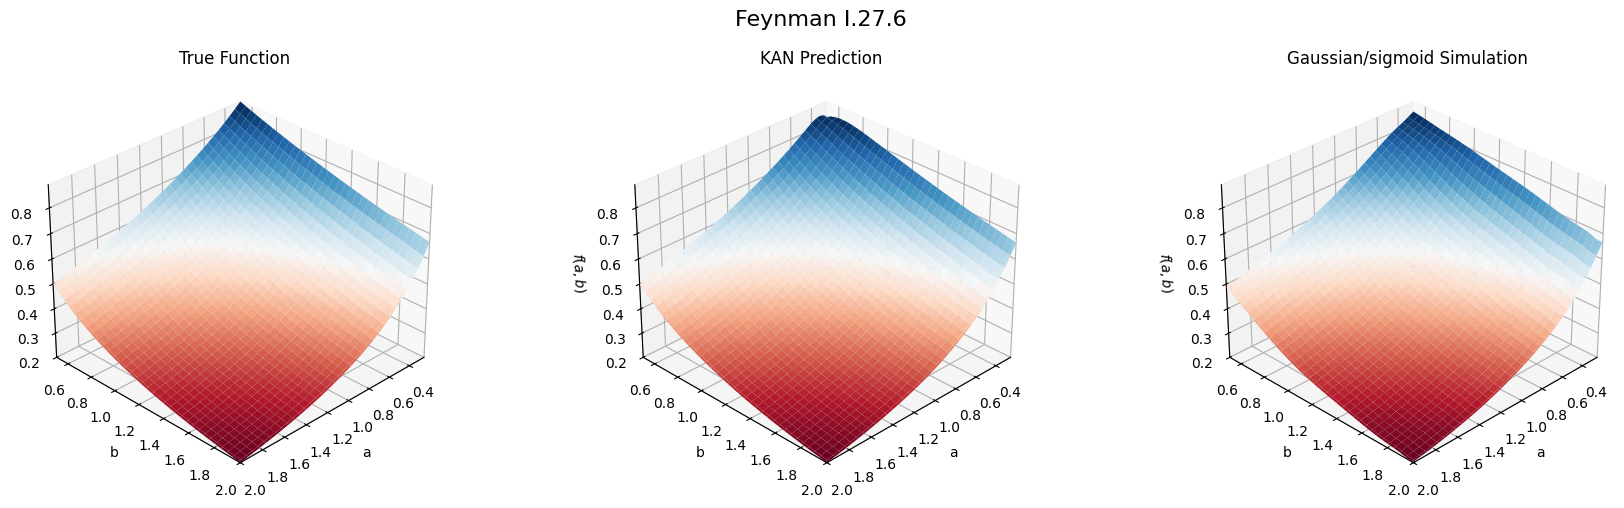

In [37]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0.25, 2)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.27.6", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.30.3**

In [38]:
f_I_30_3 = lambda n, theta: np.sin(n*theta/2)**2 / (np.sin(theta/2)**2)

n = np.linspace(0, 4, 101)
theta = np.linspace(0.4*np.pi, 1.6*np.pi, 101)
n_grid, theta_grid = np.meshgrid(n, theta)

In [39]:
def compute_KAN_tree(n_grid: np.ndarray, theta_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_30_3/")

    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    n1_x, n1_y = read_curve(curves_dir/"n1_fit_curve.csv", column_name)
    n2_x, n2_y = read_curve(curves_dir/"n2_fit_curve.csv", column_name)
    n3_x, n3_y = read_curve(curves_dir/"n3_fit_curve.csv", column_name)
    theta0_x, theta0_y = read_curve(curves_dir/"theta0_fit_curve.csv", column_name)
    theta1_x, theta1_y = read_curve(curves_dir/"theta1_fit_curve.csv", column_name)
    theta2_x, theta2_y = read_curve(curves_dir/"theta2_fit_curve.csv", column_name)
    theta3_x, theta3_y = read_curve(curves_dir/"theta3_fit_curve.csv", column_name)

    node1_0_0_x, node1_0_0_y = read_curve(curves_dir/"node1_0_0_fit_curve.csv", column_name)
    node1_0_1_x, node1_0_1_y = read_curve(curves_dir/"node1_0_1_fit_curve.csv", column_name)
    node1_0_2_x, node1_0_2_y = read_curve(curves_dir/"node1_0_2_fit_curve.csv", column_name)

    node1_1_0_x, node1_1_0_y = read_curve(curves_dir/"node1_1_0_fit_curve.csv", column_name)
    node1_1_1_x, node1_1_1_y = read_curve(curves_dir/"node1_1_1_fit_curve.csv", column_name)
    node1_1_2_x, node1_1_2_y = read_curve(curves_dir/"node1_1_2_fit_curve.csv", column_name)

    node1_2_0_x, node1_2_0_y = read_curve(curves_dir/"node1_2_0_fit_curve.csv", column_name)
    node1_2_1_x, node1_2_1_y = read_curve(curves_dir/"node1_2_1_fit_curve.csv", column_name)
    node1_2_2_x, node1_2_2_y = read_curve(curves_dir/"node1_2_2_fit_curve.csv", column_name)

    node1_3_0_x, node1_3_0_y = read_curve(curves_dir/"node1_3_0_fit_curve.csv", column_name)
    node1_3_1_x, node1_3_1_y = read_curve(curves_dir/"node1_3_1_fit_curve.csv", column_name)
    node1_3_2_x, node1_3_2_y = read_curve(curves_dir/"node1_3_2_fit_curve.csv", column_name)

    node2_0_0_x, node2_0_0_y = read_curve(curves_dir/"node2_0_0_fit_curve.csv", column_name)
    node2_1_0_x, node2_1_0_y = read_curve(curves_dir/"node2_1_0_fit_curve.csv", column_name)
    node2_2_0_x, node2_2_0_y = read_curve(curves_dir/"node2_2_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    n0_out = use_curve(n_grid, n0_x, n0_y)
    n1_out = use_curve(n_grid, n1_x, n1_y)
    n2_out = use_curve(n_grid, n2_x, n2_y)
    n3_out = use_curve(n_grid, n3_x, n3_y)

    theta0_out = use_curve(theta_grid, theta0_x, theta0_y)
    theta1_out = use_curve(theta_grid, theta1_x, theta1_y)
    theta2_out = use_curve(theta_grid, theta2_x, theta2_y)
    theta3_out = use_curve(theta_grid, theta3_x, theta3_y)

    node1_0_0in = n0_out + theta0_out
    node1_1_0in = n1_out + theta1_out
    node1_2_0in = n2_out + theta2_out
    node1_3_0in = n3_out + theta3_out

    node2_0_0in = use_curve(node1_0_0in, node1_0_0_x, node1_0_0_y) + use_curve(node1_1_0in, node1_1_0_x, node1_1_0_y) + \
                use_curve(node1_2_0in, node1_2_0_x, node1_2_0_y) + use_curve(node1_3_0in, node1_3_0_x, node1_3_0_y)

    node2_1_0in = use_curve(node1_0_0in, node1_0_1_x, node1_0_1_y) + use_curve(node1_1_0in, node1_1_1_x, node1_1_1_y) + \
                use_curve(node1_2_0in, node1_2_1_x, node1_2_1_y) + use_curve(node1_3_0in, node1_3_1_x, node1_3_1_y)

    node2_2_0in = use_curve(node1_0_0in, node1_0_2_x, node1_0_2_y) + use_curve(node1_1_0in, node1_1_2_x, node1_1_2_y) + \
                use_curve(node1_2_0in, node1_2_2_x, node1_2_2_y) + use_curve(node1_3_0in, node1_3_2_x, node1_3_2_y)

    output = use_curve(node2_0_0in, node2_0_0_x, node2_0_0_y) + use_curve(node2_1_0in, node2_1_0_x, node2_1_0_y) + \
                use_curve(node2_2_0in, node2_2_0_x, node2_2_0_y)

    return output

In [40]:
Z_true = f_I_30_3(n_grid, theta_grid)
Z_KAN = compute_KAN_tree(n_grid, theta_grid, column_name="y")
Z_simulated = compute_KAN_tree(n_grid, theta_grid, column_name="y_simulated")

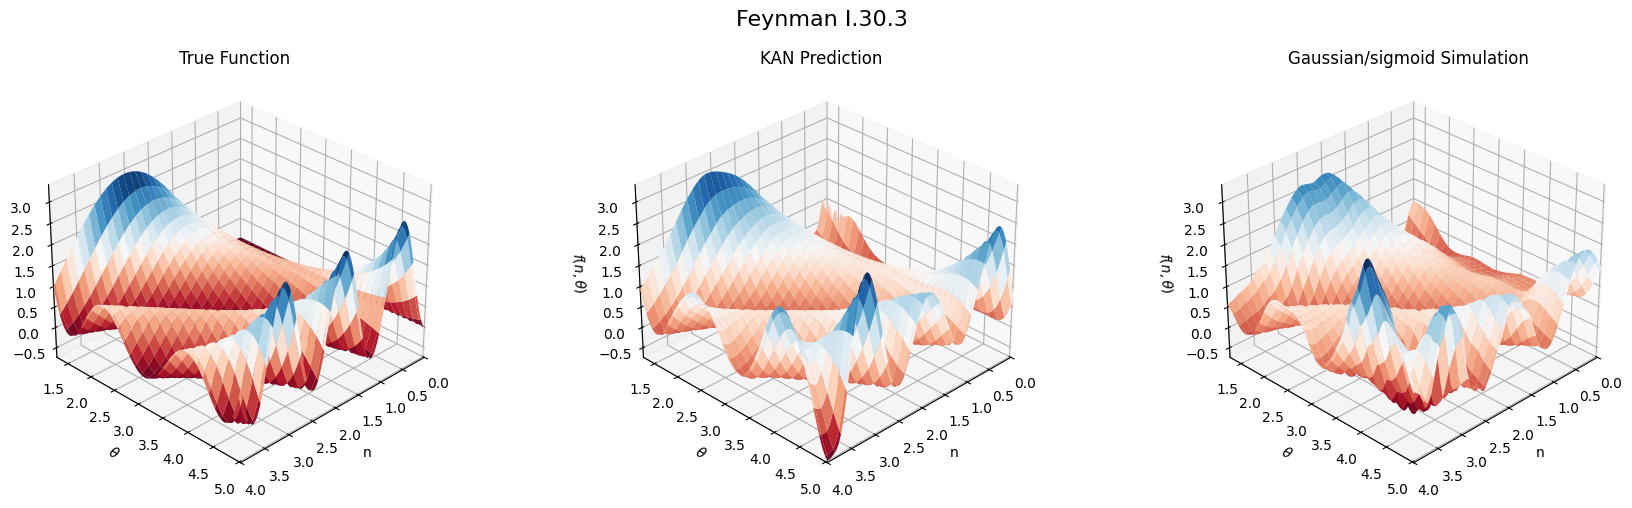

In [41]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(n_grid, theta_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("$\\theta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(n_grid, theta_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("$\\theta$")
ax2.set_zlabel("$f(n, \\theta)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(n_grid, theta_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("n")
ax3.set_ylabel("$\\theta$")
ax3.set_zlabel("$f(n, \\theta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 4)
    ax.set_ylim(0.4*np.pi, 1.6*np.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.30.3", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.30.5**

In [42]:
f_I_30_5 = lambda a, n: np.arcsin(a/n)

a = np.linspace(-1, 1, 101)
n = np.linspace(1, 1.5, 101)
a_grid, n_grid = np.meshgrid(a, n)

In [43]:
def compute_KAN_tree(a_grid: np.ndarray, n_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_30_5/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)

    n0_out = use_curve(n_grid, n0_x, n0_y)

    node1_0_in = a0_out + n0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [44]:
Z_true = f_I_30_5(a_grid, n_grid)
Z_KAN = compute_KAN_tree(a_grid, n_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, n_grid, column_name="y_simulated")

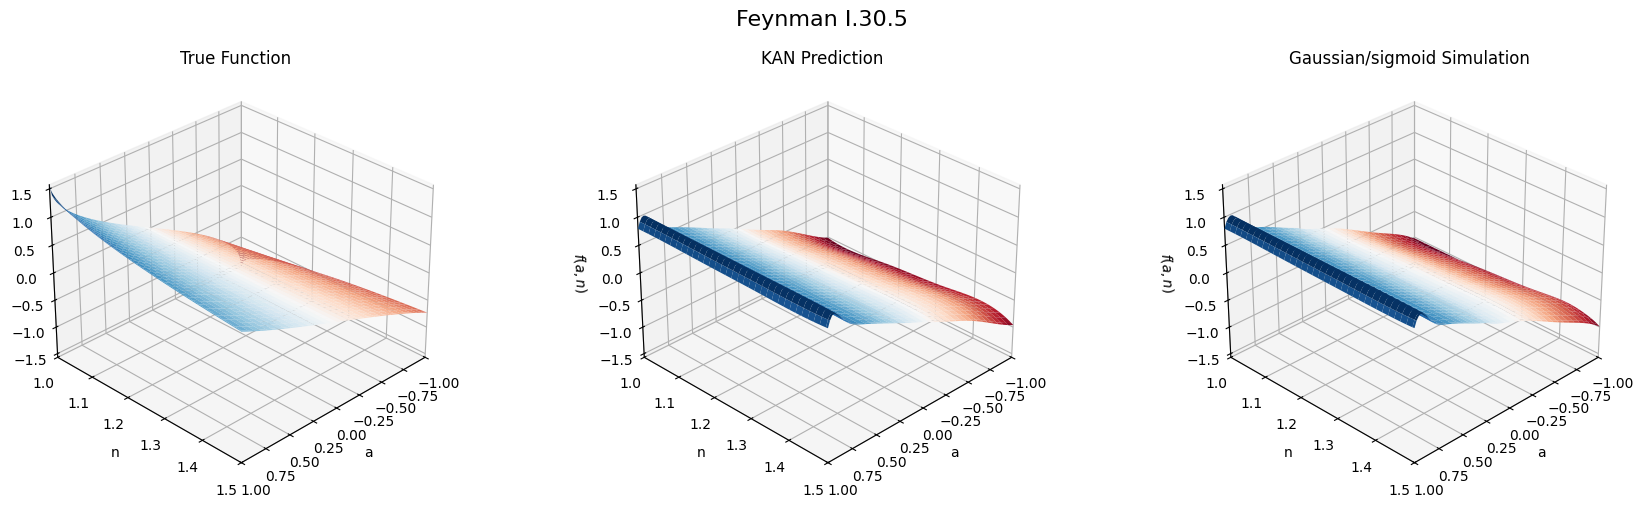

In [45]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, n_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("n")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, n_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("n")
ax2.set_zlabel("$f(a, n)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, n_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("n")
ax3.set_zlabel("$f(a, n)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(1, 1.5)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.30.5", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.37.4**

In [46]:
f_I_37_4 = lambda a, delta: 1 + a + 2*np.sqrt(a)*np.cos(delta)

a = np.linspace(0.1, 1, 101)
delta = np.linspace(0, 2*np.pi, 101)
a_grid, delta_grid = np.meshgrid(a, delta)

In [47]:
def compute_KAN_tree(a_grid: np.ndarray, delta_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_37_4/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    delta0_x, delta0_y = read_curve(curves_dir/"delta0_fit_curve.csv", column_name)
    delta1_x, delta1_y = read_curve(curves_dir/"delta1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    delta0_out = use_curve(delta_grid, delta0_x, delta0_y)
    delta1_out = use_curve(delta_grid, delta1_x, delta1_y)

    node1_0_in = a0_out + delta0_out
    node1_1_in = a1_out + delta1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [48]:
Z_true = f_I_37_4(a_grid, delta_grid)
Z_KAN = compute_KAN_tree(a_grid, delta_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, delta_grid, column_name="y_simulated")

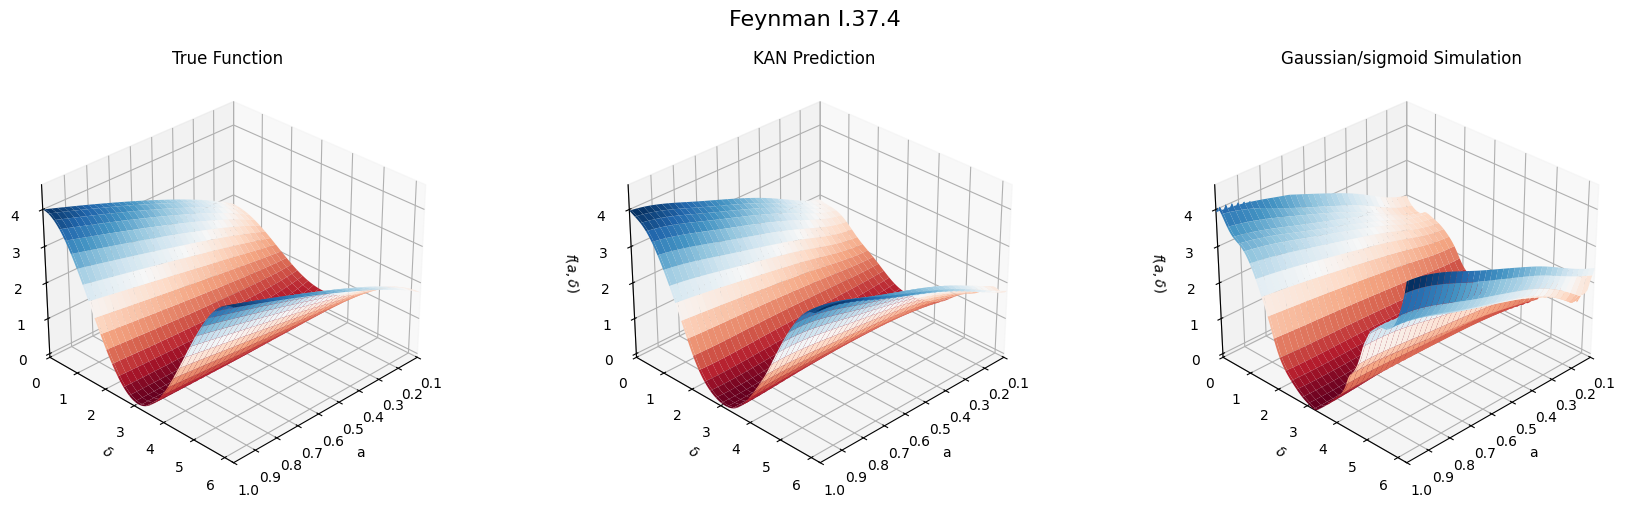

In [49]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, delta_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("$\\delta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, delta_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("$\\delta$")
ax2.set_zlabel("$f(a, \\delta)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, delta_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("$\\delta$")
ax3.set_zlabel("$f(a, \\delta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0.1, 1)
    ax.set_ylim(0, 2*np.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.37.4", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.40.1**

In [50]:
f_I_40_1 = lambda n, a: n*np.exp(-a)

n = np.linspace(0, 1, 101)
a = np.linspace(-1, 1, 101)
n_grid, a_grid = np.meshgrid(n, a)

In [51]:
def compute_KAN_tree(n_grid: np.ndarray, a_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_40_1/")

    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    n1_x, n1_y = read_curve(curves_dir/"n1_fit_curve.csv", column_name)
    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    n0_out = use_curve(n_grid, n0_x, n0_y)
    n1_out = use_curve(n_grid, n1_x, n1_y)

    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    node1_0_in = n0_out + a0_out
    node1_1_in = n1_out + a1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [54]:
Z_true = f_I_40_1(n_grid, a_grid)
Z_KAN = compute_KAN_tree(n_grid, a_grid, column_name="y")
Z_simulated = compute_KAN_tree(n_grid, a_grid, column_name="y_simulated")

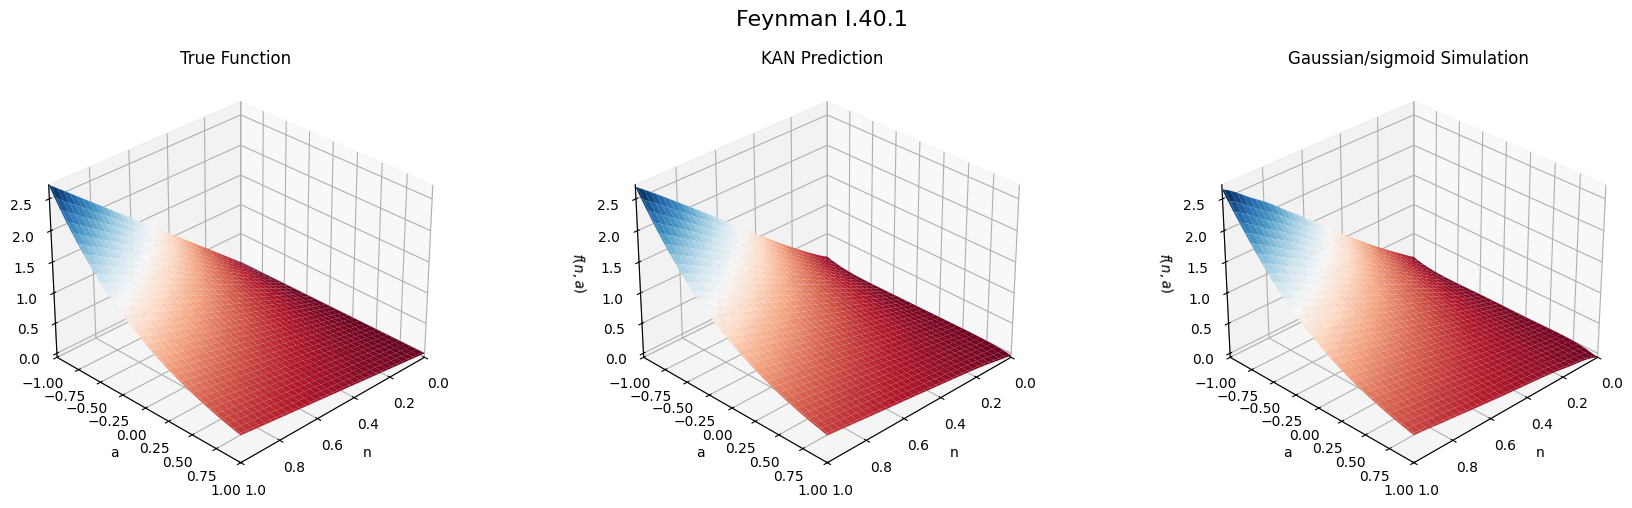

In [55]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(n_grid, a_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("a")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(n_grid, a_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("a")
ax2.set_zlabel("$f(n, a)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(n_grid, a_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("n")
ax3.set_ylabel("a")
ax3.set_zlabel("$f(n, a)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.40.1", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.44.4**

In [56]:
f_I_44_4 = lambda n, a: n*np.log(a)

n = np.linspace(0, 1, 101)
a = np.linspace(0.25, 4, 101)
n_grid, a_grid = np.meshgrid(n, a)

In [57]:
def compute_KAN_tree(n_grid: np.ndarray, a_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_44_4/")

    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    n1_x, n1_y = read_curve(curves_dir/"n1_fit_curve.csv", column_name)
    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    n0_out = use_curve(n_grid, n0_x, n0_y)
    n1_out = use_curve(n_grid, n1_x, n1_y)

    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    node1_0_in = n0_out + a0_out
    node1_1_in = n1_out + a1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [58]:
Z_true = f_I_44_4(n_grid, a_grid)
Z_KAN = compute_KAN_tree(n_grid, a_grid, column_name="y")
Z_simulated = compute_KAN_tree(n_grid, a_grid, column_name="y_simulated")

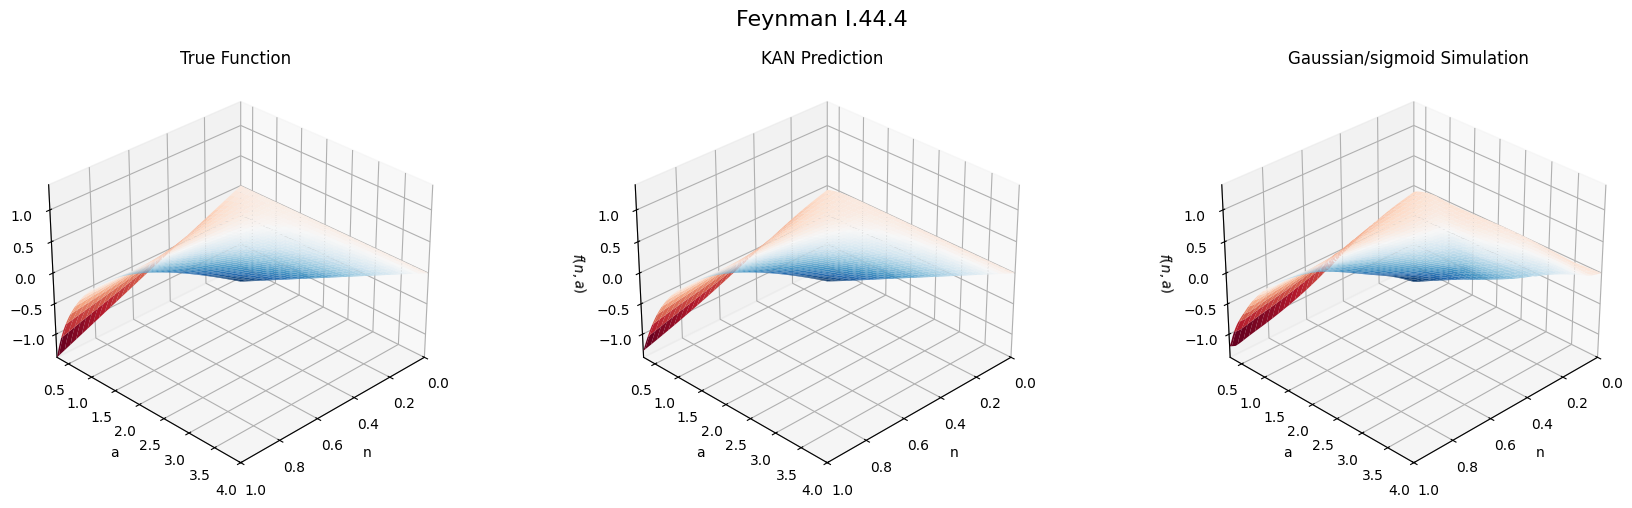

In [59]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(n_grid, a_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("a")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(n_grid, a_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("a")
ax2.set_zlabel("$f(n, a)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(n_grid, a_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("n")
ax3.set_ylabel("a")
ax3.set_zlabel("$f(n, a)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0.25, 4)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.44.4", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman I.50.26**

In [60]:
f_I_50_26 = lambda a, alpha: np.cos(a) + alpha*(np.cos(a))**2

a = np.linspace(0, 2*np.pi, 101)
alpha = np.linspace(0, 1, 101)
a_grid, alpha_grid = np.meshgrid(a, alpha)

In [64]:
def compute_KAN_tree(a_grid: np.ndarray, alpha_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_I_50_26/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    a2_x, a2_y = read_curve(curves_dir/"a2_fit_curve.csv", column_name)
    alpha0_x, alpha0_y = read_curve(curves_dir/"alpha0_fit_curve.csv", column_name)
    alpha1_x, alpha1_y = read_curve(curves_dir/"alpha1_fit_curve.csv", column_name)
    alpha2_x, alpha2_y = read_curve(curves_dir/"alpha2_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)
    node1_2_x, node1_2_y = read_curve(curves_dir/"node1_2_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)
    a2_out = use_curve(a_grid, a2_x, a2_y)

    alpha0_out = use_curve(alpha_grid, alpha0_x, alpha0_y)
    alpha1_out = use_curve(alpha_grid, alpha1_x, alpha1_y)
    alpha2_out = use_curve(alpha_grid, alpha2_x, alpha2_y)

    node1_0_in = a0_out + alpha0_out
    node1_1_in = a1_out + alpha1_out
    node1_2_in = a2_out + alpha2_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)
    node1_2_out = use_curve(node1_2_in, node1_2_x, node1_2_y)

    return node1_0_out + node1_1_out + node1_2_out

In [65]:
Z_true = f_I_50_26(a_grid, alpha_grid)
Z_KAN = compute_KAN_tree(a_grid, alpha_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, alpha_grid, column_name="y_simulated")

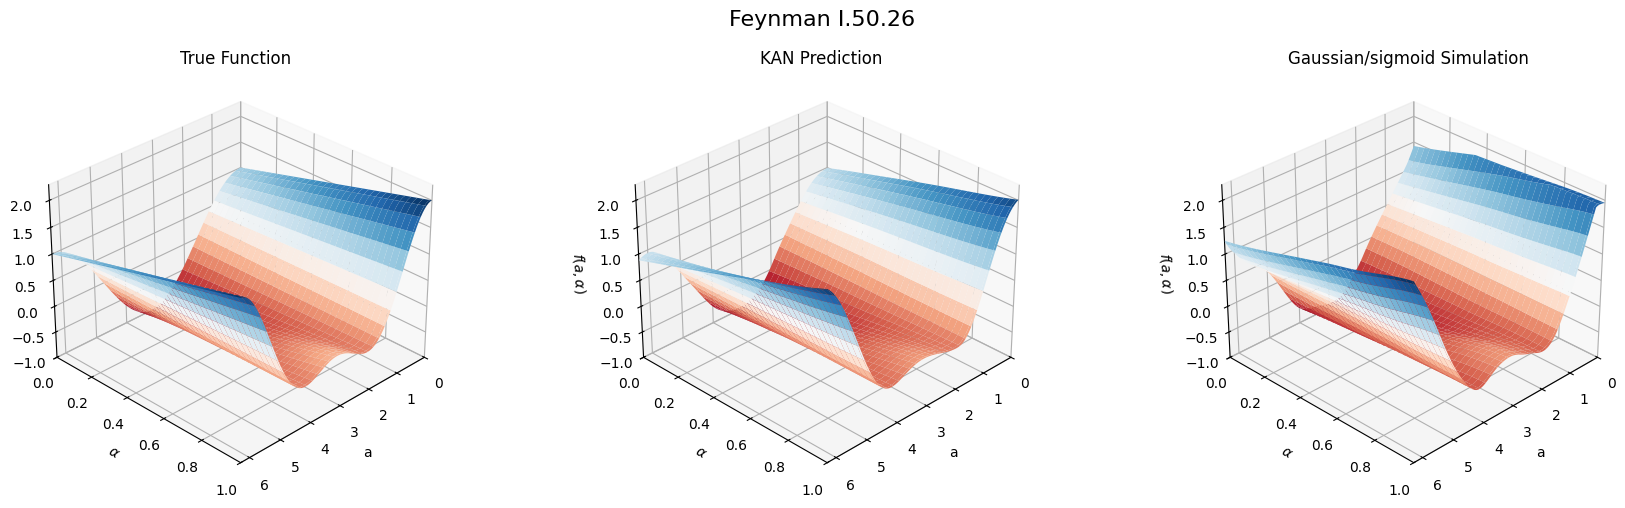

In [66]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, alpha_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("$\\alpha$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, alpha_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("$\\alpha$")
ax2.set_zlabel("$f(a, \\alpha)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, alpha_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("$\\alpha$")
ax3.set_zlabel("$f(a, \\alpha)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.50.26", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman II.2.42**

In [67]:
f_II_2_42 = lambda a, b: (a-1)*b

a = np.linspace(0, 1, 101)
b = np.linspace(0, 2, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [68]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_II_2_42/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    a1_x, a1_y = read_curve(curves_dir/"a1_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    b1_x, b1_y = read_curve(curves_dir/"b1_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)
    node1_1_x, node1_1_y = read_curve(curves_dir/"node1_1_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)
    a1_out = use_curve(a_grid, a1_x, a1_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)
    b1_out = use_curve(b_grid, b1_x, b1_y)

    node1_0_in = a0_out + b0_out
    node1_1_in = a1_out + b1_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)
    node1_1_out = use_curve(node1_1_in, node1_1_x, node1_1_y)

    return node1_0_out + node1_1_out

In [69]:
Z_true = f_II_2_42(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

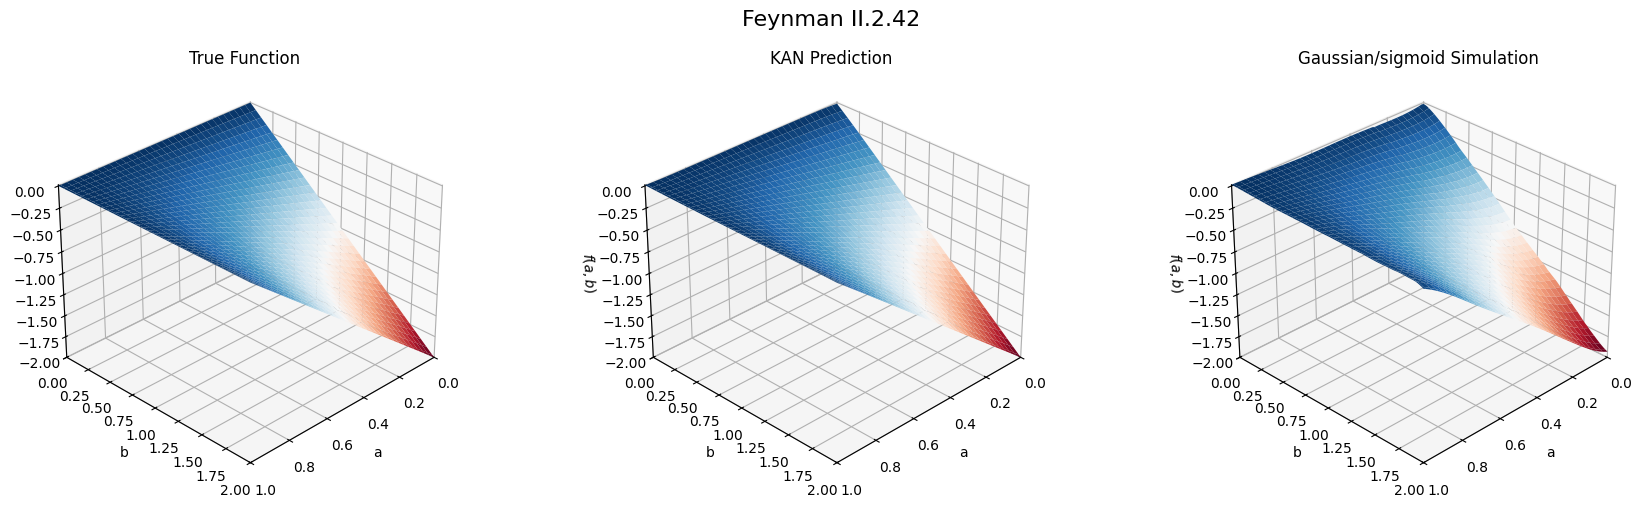

In [70]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.2.42", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman II.11.27**

In [71]:
f_II_11_27 = lambda n, alpha: (n*alpha)/(1 - (n*alpha)/3)

n = np.linspace(0, 1, 101)
alpha = np.linspace(0, 2, 101)
n_grid, alpha_grid = np.meshgrid(n, alpha)

In [74]:
def compute_KAN_tree(n_grid: np.ndarray, alpha_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_II_11_27/")

    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    alpha0_x, alpha0_y = read_curve(curves_dir/"alpha0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    n0_out = use_curve(n_grid, n0_x, n0_y)

    alpha0_out = use_curve(alpha_grid, alpha0_x, alpha0_y)

    node1_0_in = n0_out + alpha0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [75]:
Z_true = f_II_11_27(n_grid, alpha_grid)
Z_KAN = compute_KAN_tree(n_grid, alpha_grid, column_name="y")
Z_simulated = compute_KAN_tree(n_grid, alpha_grid, column_name="y_simulated")

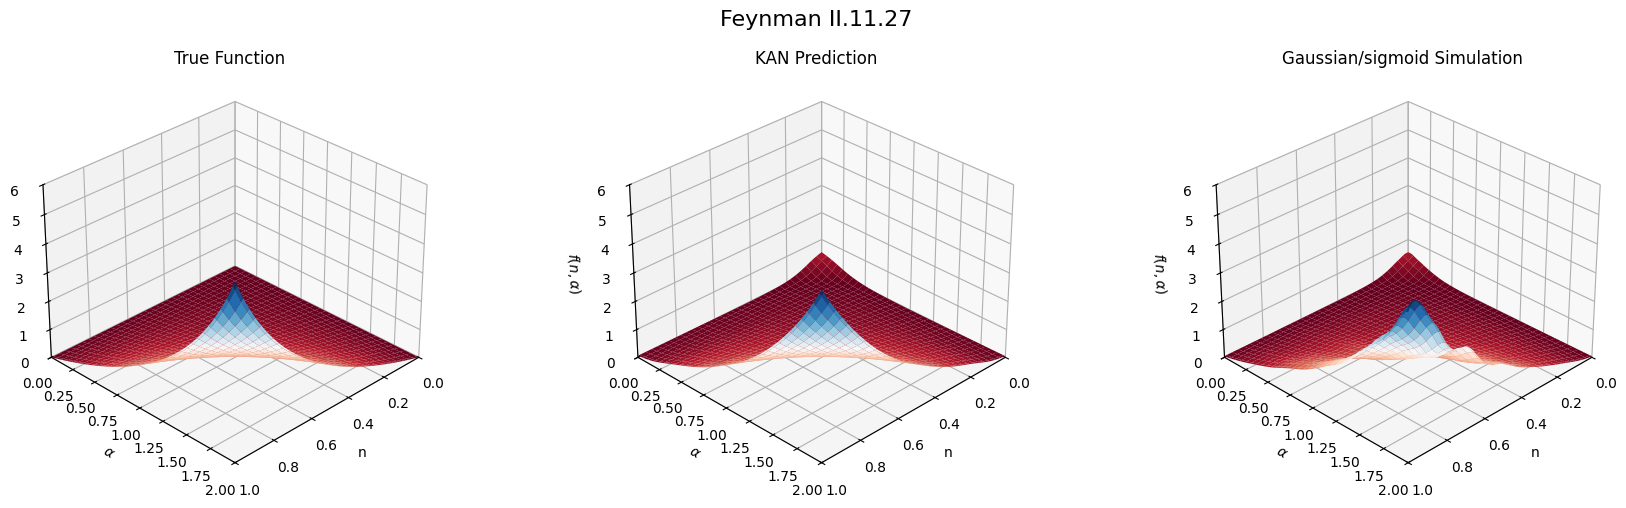

In [76]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(n_grid, alpha_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("$\\alpha$")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(n_grid, alpha_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("$\\alpha$")
ax2.set_zlabel("$f(n, \\alpha)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(n_grid, alpha_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("n")
ax3.set_ylabel("$\\alpha$")
ax3.set_zlabel("$f(n, \\alpha)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.11.27", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman II.35.18**

In [77]:
f_II_35_18 = lambda n, a: n/(np.exp(a) + np.exp(-a))

n = np.linspace(0, 1, 101)
a = np.linspace(0, 4, 101)
n_grid, a_grid = np.meshgrid(n, a)

In [78]:
def compute_KAN_tree(n_grid: np.ndarray, a_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_II_35_18/")

    n0_x, n0_y = read_curve(curves_dir/"n0_fit_curve.csv", column_name)
    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    n0_out = use_curve(n_grid, n0_x, n0_y)

    a0_out = use_curve(a_grid, a0_x, a0_y)

    node1_0_in = n0_out + a0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [79]:
Z_true = f_II_35_18(n_grid, a_grid)
Z_KAN = compute_KAN_tree(n_grid, a_grid, column_name="y")
Z_simulated = compute_KAN_tree(n_grid, a_grid, column_name="y_simulated")

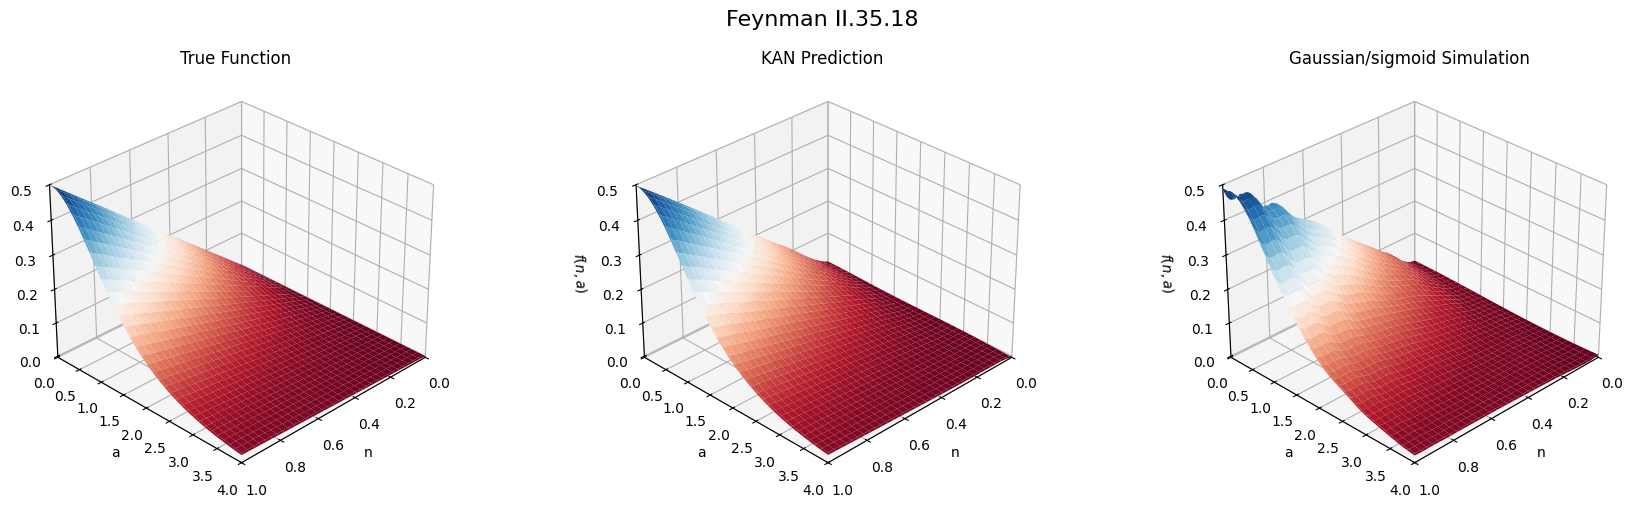

In [80]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(n_grid, a_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("a")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(n_grid, a_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("a")
ax2.set_zlabel("$f(n, a)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(n_grid, a_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("n")
ax3.set_ylabel("a")
ax3.set_zlabel("$f(n, a)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 4)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.35.18", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman II.38.3**

In [101]:
f_II_38_3 = lambda a, b: a/b

a = np.linspace(0, 1, 101)
b = np.linspace(0.5, 2, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [102]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_II_38_3/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)

    node1_0_in = a0_out + b0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [103]:
Z_true = f_II_38_3(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

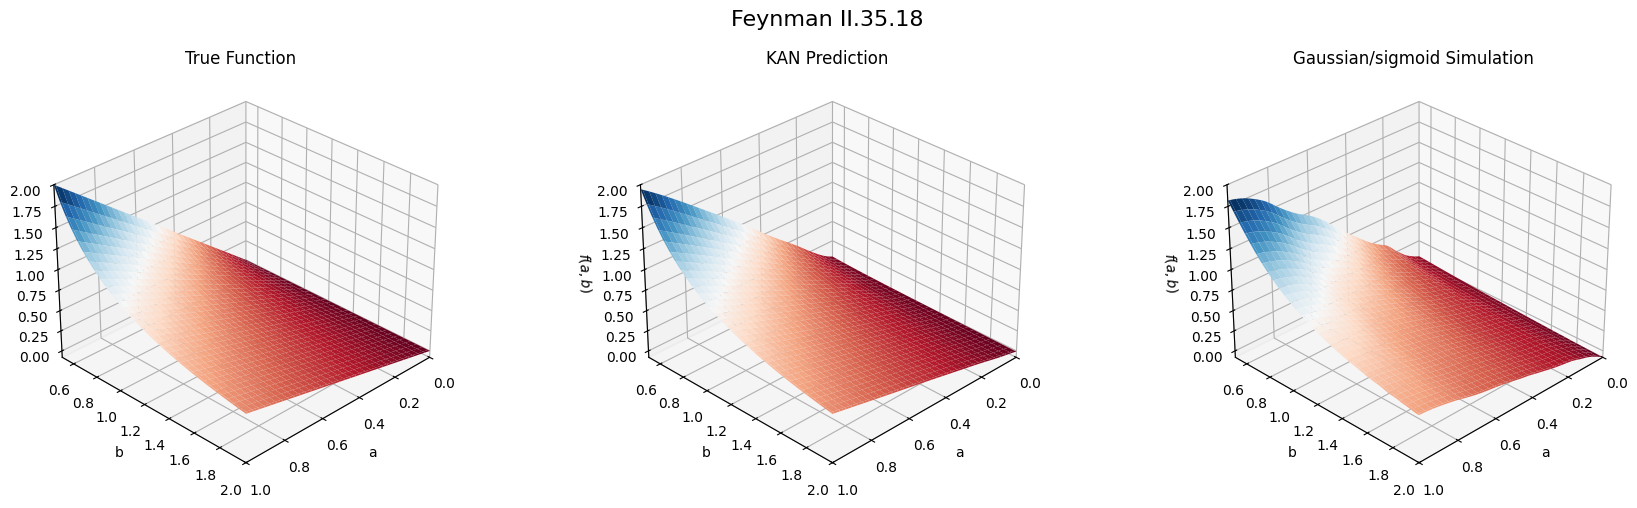

In [105]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.35.18", fontsize=16)
plt.tight_layout()
plt.show()

**Feynman III.10.19**

In [106]:
f_III_10_19 = lambda a, b: np.sqrt(1 + a**2 + b**2)

a = np.linspace(0, 1, 101)
b = np.linspace(0, 1, 101)
a_grid, b_grid = np.meshgrid(a, b)

In [107]:
def compute_KAN_tree(a_grid: np.ndarray, b_grid: np.ndarray, column_name: str):
    '''Loads and computes the KAN tree result for either the original or simulated curve based on the provided column_name'''

    # Load all curves from the folder
    curves_dir = Path("fit_KAN_Feynman_activation_funcs/Feynman_III_10_19/")

    a0_x, a0_y = read_curve(curves_dir/"a0_fit_curve.csv", column_name)
    b0_x, b0_y = read_curve(curves_dir/"b0_fit_curve.csv", column_name)
    node1_0_x, node1_0_y = read_curve(curves_dir/"node1_0_fit_curve.csv", column_name)

    # Compute data points following the KAN structure
    a0_out = use_curve(a_grid, a0_x, a0_y)

    b0_out = use_curve(b_grid, b0_x, b0_y)

    node1_0_in = a0_out + b0_out

    node1_0_out = use_curve(node1_0_in, node1_0_x, node1_0_y)

    return node1_0_out

In [108]:
Z_true = f_III_10_19(a_grid, b_grid)
Z_KAN = compute_KAN_tree(a_grid, b_grid, column_name="y")
Z_simulated = compute_KAN_tree(a_grid, b_grid, column_name="y_simulated")

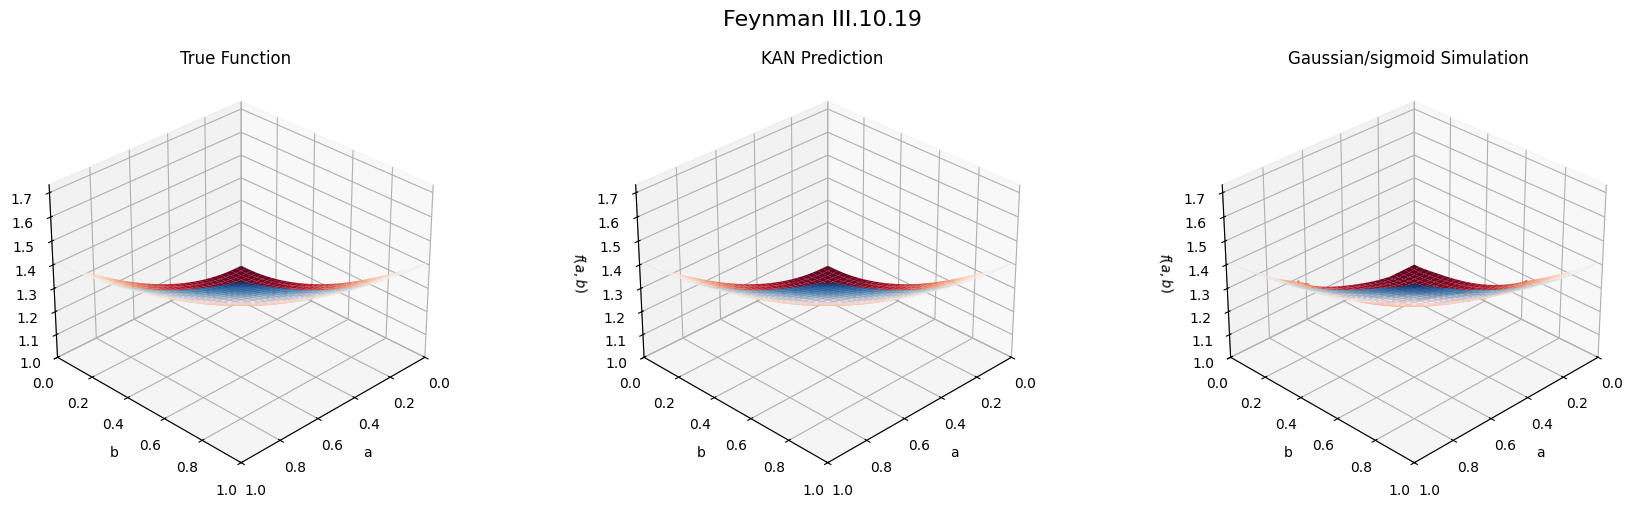

In [109]:
# Plot the final results for true vs KAN vs Gaussian/sigmoid simulated
fig = plt.figure(figsize=(18,5))

# --- True function ---
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(a_grid, b_grid, Z_true, cmap='RdBu')
ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(a_grid, b_grid, Z_KAN, cmap='RdBu')
ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Gauss/sig simulation ---
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(a_grid, b_grid, Z_simulated, cmap='RdBu')
ax3.set_title("Gaussian/sigmoid Simulation")
ax3.set_xlabel("a")
ax3.set_ylabel("b")
ax3.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_KAN.min(), Z_simulated.min())
zmax = max(Z_true.max(), Z_KAN.max(), Z_simulated.max())

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman III.10.19", fontsize=16)
plt.tight_layout()
plt.show()